# 02 - Feature Engineering
Engineered features: `Assessment_Avg`, `Attendance_Status`, `Engagement_Score`, `Academic_Performance_Index`.

In [1]:
import sys; sys.path.insert(0, '..')
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
from IPython.display import Image, display
from src.utils import *
from src.feature_engineering import add_features
df = pd.read_csv(PROCESSED_PATH)
df[['Student_ID'] + ENGINEERED + ['Risk_Level']].head(10)

,Student_ID,Assessment_Avg,Attendance_Status,Engagement_Score,Academic_Performance_Index,Risk_Level
0,STU00001,70.22,1,68.48,72.16,Medium
1,STU00002,60.42,1,65.72,62.52,Medium
2,STU00003,76.45,0,82.38,81.11,Low
3,STU00004,81.30,0,67.26,79.88,Low
4,STU00005,22.62,2,42.80,35.08,High
5,STU00006,50.52,1,64.10,59.26,Medium
6,STU00007,55.48,1,62.72,64.16,Medium
7,STU00008,54.75,1,48.68,58.89,Medium
8,STU00009,63.25,1,70.50,67.32,Low
9,STU00010,52.20,1,70.48,62.89,Medium


## Do the engineered features separate the risk classes?

In [2]:
df.groupby('Risk_Level')[ENGINEERED].mean().loc[RISK_LABELS].round(2)

,Assessment_Avg,Attendance_Status,Engagement_Score,Academic_Performance_Index
Risk_Level,,,,
Low,71.32,0.41,72.62,75.99
Medium,59.13,1.00,60.15,64.33
High,48.85,1.50,51.21,54.50


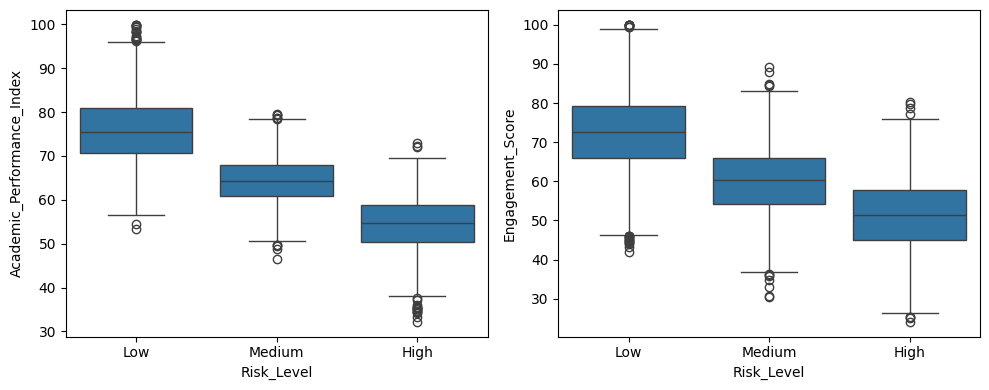

In [3]:
import matplotlib.pyplot as plt, seaborn as sns
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(data=df, x='Risk_Level', y='Academic_Performance_Index', order=RISK_LABELS, ax=ax[0])
sns.boxplot(data=df, x='Risk_Level', y='Engagement_Score', order=RISK_LABELS, ax=ax[1])
plt.tight_layout()

## Unsupervised view: K-Means student groups + association rules

[clustering] silhouette(k=3)=0.306
                              Attendance_Percentage  Assessment_Avg  \
Cluster_Name                                                          
Struggling & disengaged                        64.1            51.3   
Average / inconsistent                         76.8            63.8   
High attendance + high marks                   89.1            76.4   

                              Previous_GPA  Study_Hours  Engagement_Score  \
Cluster_Name                                                                
Struggling & disengaged                5.7          1.7              51.2   
Average / inconsistent                 6.9          3.0              65.2   
High attendance + high marks           8.1          4.3              79.5   

                              Final_Score  Students  
Cluster_Name                                         
Struggling & disengaged              48.0      1676  
Average / inconsistent               65.9      2702  
High at

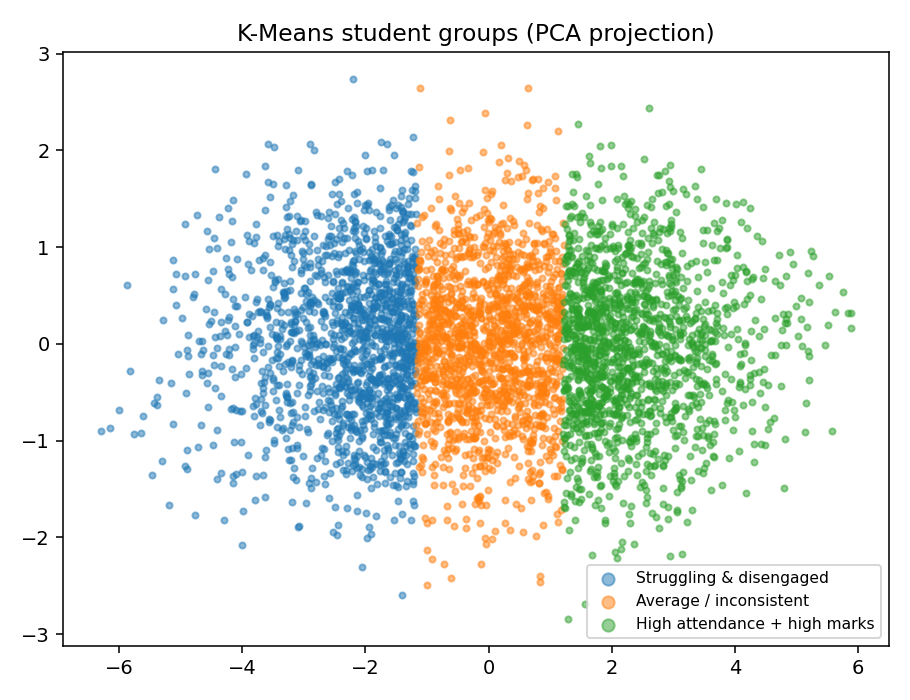

Risk_Level,Low,Medium,High
Cluster_Name,,,
Struggling & disengaged,0.048,0.416,0.535
Average / inconsistent,0.545,0.409,0.046
High attendance + high marks,0.973,0.026,0.001


In [4]:
from src import clustering, association
profile, xt = clustering.main()
display(Image(str(FIG_DIR / 'cluster_pca.png'), width=480))
xt

In [5]:
association.main().head(10)

[association] 40 rules -> reports/association_rules.csv
                                                              antecedents consequents  support  confidence  lift
   Low assessment (<50) + Low attendance (<65%) + Low previous GPA (<5.5) Risk = High    0.046       0.958 5.620
  Low attendance (<65%) + Low previous GPA (<5.5) + Low study hours (<2h) Risk = High    0.040       0.949 5.566
           Has backlogs + Low attendance (<65%) + Low previous GPA (<5.5) Risk = High    0.041       0.947 5.552
Low attendance (<65%) + Low participation (<45) + Low previous GPA (<5.5) Risk = High    0.034       0.945 5.542
              Has backlogs + Low assessment (<50) + Low attendance (<65%) Risk = High    0.046       0.942 5.525
     Low assessment (<50) + Low attendance (<65%) + Low study hours (<2h) Risk = High    0.049       0.933 5.474
   Low assessment (<50) + Low previous GPA (<5.5) + Low study hours (<2h) Risk = High    0.046       0.930 5.455
Low participation (<45) + Low previous G

,antecedents,consequents,support,confidence,lift
159,Low assessment (<50) + Low attendance (<65%) +...,Risk = High,0.046,0.958,5.620
215,Low attendance (<65%) + Low previous GPA (<5.5...,Risk = High,0.040,0.949,5.566
221,Has backlogs + Low attendance (<65%) + Low pre...,Risk = High,0.041,0.947,5.552
226,Low attendance (<65%) + Low participation (<45...,Risk = High,0.034,0.945,5.542
194,Has backlogs + Low assessment (<50) + Low atte...,Risk = High,0.046,0.942,5.525
180,Low assessment (<50) + Low attendance (<65%) +...,Risk = High,0.049,0.933,5.474
267,Low assessment (<50) + Low previous GPA (<5.5)...,Risk = High,0.046,0.930,5.455
326,Low participation (<45) + Low previous GPA (<5...,Risk = High,0.034,0.928,5.440
290,Low assessment (<50) + Low participation (<45)...,Risk = High,0.039,0.925,5.425
315,Has backlogs + Low assessment (<50) + Low part...,Risk = High,0.039,0.925,5.425
